In [1]:
import torch
from data_split import load_data, concat_datasets
import numpy as np
import random

seed = 2025
random.seed(seed)
torch.manual_seed(seed)
np.random.seed(seed)
torch.cuda.manual_seed(seed)
rng = np.random.default_rng(seed)
torch.cuda.manual_seed_all(seed)

# choose from "PBMC", "Mouse-Cortex", "Mouse-Skin", "Human-Kidney", "Mouse-MOp", "BMMC", "CL", "UP_HK"
dataset_name = "Mouse-MOp-RNA"  # Human-Kidney Pancreas TMS PancreasHumanMouse Baron_Human_Mouse_Normalized ImmuneHumanMouse(2) Lung PurifiedPBMCDataset TS_Bone_Marrow TS_Skin Dorsal_Midbrain BGI PBMC_Time(2) PBMC_Sub Immune_PBMC_Human_Mouse Colorectal_Cancer Breast_Cancer RCC HGSOC BMMC_Kidney TMS_Fat_Limb TMS_marrow_spleen Mus_Kidney Giraddi_10x Han Hochane mice_zebrafish human_cortex_EaFet_Adol Zeisel_p20_p23 Zeisel_p20_p29 Retina_Human_Mouse Retina_Human_Mouse_v2 Retina_Human_Mouse_v3 Thymus_Cao_ALIGNED Liver_Human_Monkey TMS_Thymus mouse_heart_pancreas HNSCC_RNA CL_ATAC PBMC_ATAC_ASAP_seq BoneMarrowA_BoneMarrowB
setting = "setting1"  # setting1 setting3

omics = 1
if omics == 1:
    omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood, gene_name =load_data(dataset_name, setting, omics=1)
    if omics1_test_id_loader is None:
        omics1_mixed_loader = omics1_test_ood_loader
    else:
        omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
        all_data_loader = concat_datasets(omics1_train_loader, omics1_mixed_loader)
elif omics == 2:
    omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics2_train_loader, omics2_test_id_loader, omics2_test_ood_loader, global_categories_id, global_categories_ood, mapping_ood =load_data(dataset_name, setting, omics=1)

    omics1_mixed_loader = concat_datasets(omics1_test_id_loader, omics1_test_ood_loader)
    omics2_mixed_loader = concat_datasets(omics2_test_id_loader, omics2_test_ood_loader)

print(f'ID: {global_categories_id}')
print(f'OOD: {global_categories_ood}')
print(f'Mapping OOD: {mapping_ood}')

print(len(global_categories_id))

ModuleNotFoundError: No module named 'data_split'

当前工作目录: /tmp/5dlyoVgkrZ
当前目录文件: []


In [2]:
from scDiscovery_architecture import *
import torch.optim as optim

class_number = len(global_categories_id)

device = torch.device("cuda:3")

if omics == 1:
    omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]
    
    E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
    Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)
    
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
elif omics == 2:
    omics1_imput_size = omics1_train_loader.dataset[0][0].shape[0]
    omics2_imput_size = omics2_train_loader.dataset[0][0].shape[0]
    
    E_rna = Encoder(input_size=omics1_imput_size, z_dim=128).to(device)
    E_atac = Encoder(input_size=omics2_imput_size, z_dim=128).to(device)
    Classifier = JointClassificationHead(z_dim=128, n_classes=class_number).to(device)
    
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)


In [3]:
from scDiscovery_architecture import Decoder
from scDiscovery_step5_decoder import train_decoder_classification, train_decoder_classification_single_omics

if omics == 1:
    D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)
    
    optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
    
    E_rna, D_rna, Classifier = train_decoder_classification_single_omics(E_rna, D_rna, Classifier, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, num_epochs=5, device=device)
elif omics == 2:
    D_rna = Decoder(input_size=omics1_imput_size, z_dim=128).to(device)
    D_atac = Decoder(input_size=omics2_imput_size, z_dim=128).to(device)
    
    optimizer_D_rna = optim.Adam(D_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_D_atac = optim.Adam(D_atac.parameters(), lr=0.01, weight_decay=1e-4)
    
    scheduler_D_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_rna, T_max=100)
    scheduler_D_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_D_atac, T_max=100)
    
    E_rna, E_atac, D_rna, D_atac, Classifier = train_decoder_classification(E_rna, E_atac, D_rna, D_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_D_rna, optimizer_D_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_D_rna, scheduler_D_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics2_train_loader, omics2_test_id_loader, num_epochs=5, device=device)


Epoch [1/5], CLS Loss: 0.3268, RNA Recon Loss: 165.6251, RNA KL Loss: 0.6330, Acc_train: 97.96, Acc_test: 95.47
Epoch [2/5], CLS Loss: 0.0650, RNA Recon Loss: 113.0177, RNA KL Loss: 0.8233, Acc_train: 98.53, Acc_test: 96.32
Epoch [3/5], CLS Loss: 0.0441, RNA Recon Loss: 84.6603, RNA KL Loss: 0.8219, Acc_train: 98.79, Acc_test: 96.85
Epoch [4/5], CLS Loss: 0.0410, RNA Recon Loss: 71.0821, RNA KL Loss: 0.8277, Acc_train: 98.63, Acc_test: 96.71
Epoch [5/5], CLS Loss: 0.0389, RNA Recon Loss: 62.0292, RNA KL Loss: 0.8345, Acc_train: 98.86, Acc_test: 97.07


In [6]:
from scDiscovery_step2_OOD import train_distinguish_id_ood, train_distinguish_id_ood_with_single_omics, get_detected_ood_data_with_single_omics

# TMs: 0.4, 0.0; Baron_Human_Mouse: 0.1, 0.0; Pancreas: 0.5, 0.0; TS_Bone_Marrow:0.3, 0.0; PurifiedPBMCDataset: 0.6, 0.0; PBMC_Time: 0.7, 0.0; PBMC_Sub: 0.5, 0.0; HGSOC: 0.7, 0.0; BMMC_Kidney: 0.7, 0.0; TMS_Fat_Limb: 0.5, 0.0, Zeisel_p20_p29: 0.4(or 0.5), 0.0, mice_zebrafish: 0.4, 0.0; Liver_Human_Monkey: 0.9, 0.0

threshold = 0.8

if omics == 1:
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.001, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.001, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
    # filtered_omics1_ood_loader, filtered_omics1_id_loader = get_detected_ood_data_with_single_omics(E_rna, Classifier, omics1_mixed_loader, final_threshold=0.6)
    
    E_rna, Classifier, filtered_omics1_ood_loader, filtered_omics1_id_loader = train_distinguish_id_ood_with_single_omics(E_rna, Classifier, optimizer_E_rna, optimizer_fc, scheduler_E_rna, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics1_mixed_loader, class_number=class_number, num_iters=1, num_epochs=5, recall_level=0.95, threshold=threshold, device=device)  # (2,5) 5
elif omics == 2:
    optimizer_E_rna = optim.Adam(E_rna.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_E_atac = optim.Adam(E_atac.parameters(), lr=0.01, weight_decay=1e-4)
    optimizer_fc = optim.Adam(Classifier.parameters(), lr=0.01, weight_decay=1e-4)
    
    scheduler_E_rna = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_rna, T_max=100)
    scheduler_E_atac = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_E_atac, T_max=100)
    scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)
    
    E_rna, E_atac, Classifier, filtered_omics1_ood_loader, filtered_omics2_ood_loader, filtered_omics1_id_loader, filtered_omics2_id_loader = train_distinguish_id_ood(E_rna, E_atac, Classifier, optimizer_E_rna, optimizer_E_atac, optimizer_fc, scheduler_E_rna, scheduler_E_atac, scheduler_fc, omics1_train_loader, omics1_test_id_loader, omics1_test_ood_loader, omics2_train_loader, omics2_test_id_loader, omics2_test_ood_loader, omics1_mixed_loader, omics2_mixed_loader, class_number=class_number, num_iters=5, num_epochs=1, recall_level=0.95, device=device)  # (2,5)

  FPR95 AUROC AUPR
& 30.92 & 95.93 & 99.47
0.85368896
Iteration 1
Threshold in This Iter:0.8
  FPR95 AUROC AUPR
& 5.58 & 97.79 & 99.72
0.45969123
  FPR95 AUROC AUPR
& 2.21 & 98.13 & 99.77
0.532359
  FPR95 AUROC AUPR
& 1.59 & 98.27 & 99.78
0.54334277
  FPR95 AUROC AUPR
& 1.52 & 98.31 & 99.79
0.52396536
  FPR95 AUROC AUPR
& 1.39 & 98.34 & 99.79
0.52117103


In [9]:
from scDiscovery_step2_OOD import train_distinguish_id_ood, train_distinguish_id_ood_with_single_omics, get_detected_ood_data_with_single_omics

threshold = 0.2

filtered_omics1_ood_loader, filtered_omics1_id_loader = get_detected_ood_data_with_single_omics(E_rna, Classifier, omics1_mixed_loader, threshold, device=device)

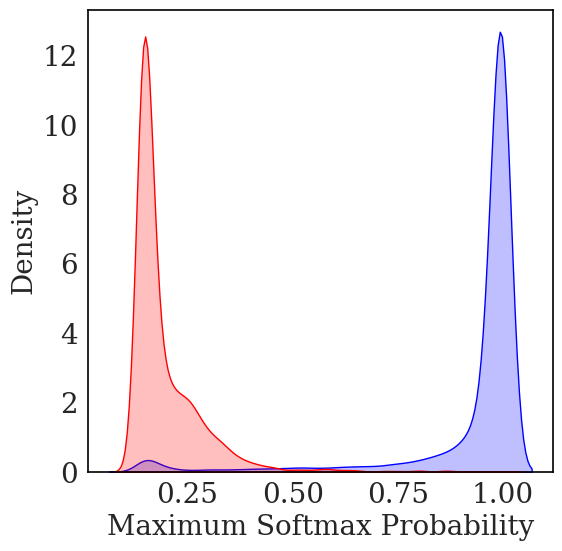

In [7]:
from scDiscovery_step2_OOD import get_ood_scores_with_single_omics

if omics1_test_id_loader is None:
    omics1_test_id_loader = omics1_train_loader

id_scores, _, _, _ = get_ood_scores_with_single_omics(E_rna, Classifier, omics1_test_id_loader, device)
ood_scores, _, _, _ = get_ood_scores_with_single_omics(E_rna, Classifier, omics1_test_ood_loader, device)


# 设定一个阈值（例如 0.6，具体需观察分布直方图决定）
threshold = 0.95
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# ===== 全局绘图样式统一 =====
plt.rcParams["font.family"] = "DejaVu Serif"   # 可改成 "Arial" / "Times New Roman"
plt.rcParams["font.size"] = 20
plt.rcParams["axes.titlesize"] = 20
plt.rcParams["axes.labelsize"] = 20
plt.rcParams["xtick.labelsize"] = 20
plt.rcParams["ytick.labelsize"] = 20
plt.rcParams["legend.fontsize"] = 15
plt.rcParams["legend.title_fontsize"] = 16

plt.rcParams["figure.facecolor"] = "white"
plt.rcParams["axes.facecolor"] = "white"
plt.rcParams["savefig.facecolor"] = "white"

plt.rcParams["axes.edgecolor"] = "black"
plt.rcParams["axes.linewidth"] = 1.2
plt.rcParams["grid.alpha"] = 0.0

plt.figure(figsize=(6, 6))  # (10, 6)

sns.kdeplot(
    id_scores,
    label="Known",
    fill=True,
    color="blue"
)

sns.kdeplot(
    ood_scores,
    label="Unknown",
    fill=True,
    color="red"
)

plt.xlabel("Maximum Softmax Probability")
plt.ylabel("Density")
plt.grid(False)

ax = plt.gca()
for spine in ax.spines.values():
    spine.set_visible(True)

# 主图不显示 legend 的话，就不要 plt.legend()
plt.savefig(f"scDiscovery_density_{dataset_name}_{setting}.pdf", dpi=600, bbox_inches="tight")
plt.show()

# =========================
# 单独导出 legend
# =========================
legend_elements = [
    Patch(facecolor="blue", edgecolor="blue", label="Known", alpha=0.6),
    Patch(facecolor="red", edgecolor="red", label="Unknown", alpha=0.6),
]

fig_legend = plt.figure(figsize=(3, 1.2))
fig_legend.legend(
    handles=legend_elements,
    loc="center",
    ncol=2,
    framealpha=0.1,
    frameon=False
)

fig_legend.savefig(
    f"scDiscovery_legend_{dataset_name}_{setting}.pdf",
    dpi=600,
    bbox_inches="tight",
    transparent=True
)
plt.close(fig_legend)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import gaussian_kde
from matplotlib.patches import Patch

def horizontal_half_violin(
    ax, data, y0, side='up', height=0.32,
    color='#4F46E5', alpha=0.28, lw=2.2,
    bw=0.18, scatter=True, s=10, scatter_alpha=0.10,
    label=None
):
    data = np.asarray(data)
    data = data[np.isfinite(data)]

    # 在数据范围附近估计 KDE
    x_min = max(0.0, np.percentile(data, 0.2) - 0.03)
    x_max = min(1.02, np.percentile(data, 99.8) + 0.03)
    x = np.linspace(x_min, x_max, 500)

    kde = gaussian_kde(data, bw_method=bw)
    dens = kde(x)
    dens = dens / dens.max() * height

    if side == 'up':
        ax.fill_between(x, y0, y0 + dens, color=color, alpha=alpha, linewidth=0)
        ax.plot(x, y0 + dens, color=color, lw=lw, solid_capstyle='round')
        if scatter:
            ys = y0 + np.random.uniform(0.01, height * 0.85, len(data))
    else:
        ax.fill_between(x, y0, y0 - dens, color=color, alpha=alpha, linewidth=0)
        ax.plot(x, y0 - dens, color=color, lw=lw, solid_capstyle='round')
        if scatter:
            ys = y0 - np.random.uniform(0.01, height * 0.85, len(data))

    if scatter:
        ax.scatter(data, ys, s=s, color=color, alpha=scatter_alpha, zorder=3)

    # 中位数和四分位，做成细小的箱线标记
    q1, med, q3 = np.percentile(data, [25, 50, 75])
    box_h = 0.055
    ax.add_patch(
        plt.Rectangle(
            (q1, y0 - box_h/2), q3 - q1, box_h,
            facecolor='white', edgecolor=color, lw=1.8, zorder=4
        )
    )
    ax.plot([med, med], [y0 - box_h/2, y0 + box_h/2], color=color, lw=2.0, zorder=5)

    if label is not None:
        return Patch(facecolor=color, edgecolor=color, alpha=alpha, label=label)


# ===== 你的数据 =====
known_msp = id_scores
unknown_msp = ood_scores

plt.rcParams.update({
    "font.family": "serif",
    "font.size": 14,
    "axes.titlesize": 22,
    "axes.labelsize": 18,
    "xtick.labelsize": 14,
    "ytick.labelsize": 16,
})

fig, ax = plt.subplots(figsize=(10, 5), dpi=180)

h1 = horizontal_half_violin(
    ax, known_msp, y0=1.0, side='up',
    color='#4361EE', alpha=0.25, bw=0.12,
    scatter=True, scatter_alpha=0.10, label='Known'
)

h2 = horizontal_half_violin(
    ax, unknown_msp, y0=0.0, side='down',
    color='#F94144', alpha=0.25, bw=0.12,
    scatter=True, scatter_alpha=0.10, label='Unknown'
)

ax.set_xlim(0.0, 1.05)
ax.set_ylim(-0.55, 1.55)
ax.set_yticks([0.0, 1.0])
ax.set_yticklabels(['Unknown', 'Known'])
ax.set_xlabel('Maximum Softmax Probability')
ax.set_title('Half Violin Plot of MSP Distribution', pad=14)

ax.grid(axis='x', linestyle='--', linewidth=0.8, alpha=0.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.2)
ax.spines['bottom'].set_linewidth(1.2)

ax.legend(handles=[h1, h2], frameon=False, loc='upper center', ncol=2)

plt.savefig('./figures/density/half_violin.png', dpi=300, bbox_inches="tight")
# plt.tight_layout()
plt.show()

In [8]:
import numpy as np
from sklearn.neighbors import KernelDensity
from sklearn.mixture import GaussianMixture


def _count_peaks_kde(scores, grid_size=2048, bandwidth=None, min_peak_ratio=0.2):
    """
    返回(peak_count, mode_value)

    min_peak_ratio:
        第二峰高度 / 主峰高度 < 该值 → 视为单峰
        推荐:
            0.1 非常宽松（几乎都算单峰）
            0.2–0.3 工程稳健 ⭐推荐
            0.4+ 比较严格
    """
    s = np.asarray(scores, dtype=float)
    s = s[np.isfinite(s)]

    if bandwidth is None:
        std = float(np.std(s))
        n = len(s)
        bw = 1.06 * std * (n ** (-1 / 5)) if std > 0 else 0.01
        bandwidth = float(np.clip(bw, 1e-3, 0.2))

    grid = np.linspace(float(s.min()), float(s.max()), grid_size)
    kde = KernelDensity(kernel="gaussian", bandwidth=bandwidth).fit(s.reshape(-1, 1))
    dens = np.exp(kde.score_samples(grid.reshape(-1, 1)))

    peaks = np.where((dens[1:-1] > dens[:-2]) & (dens[1:-1] > dens[2:]))[0] + 1

    if len(peaks) == 0:
        mode_idx = int(np.argmax(dens))
        return 1, float(grid[mode_idx]), bandwidth

    # ⭐ NEW: 峰高度过滤（关键修复）
    peak_heights = dens[peaks]
    order = np.argsort(peak_heights)[::-1]

    main_peak = peak_heights[order[0]]

    if len(order) == 1:
        peak_cnt = 1
    else:
        second_peak = peak_heights[order[1]]
        ratio = second_peak / main_peak

        if ratio < min_peak_ratio:
            peak_cnt = 1   # ⭐ 视为单峰
        else:
            peak_cnt = len(peaks)

    mode_idx = peaks[order[0]]
    return int(peak_cnt), float(grid[mode_idx]), bandwidth


def gmm_threshold_msp(scores,
                      n_init=20,
                      random_state=0,
                      reg_covar=1e-6,
                      method="equal_likelihood",
                      prior_id=None,
                      prior_ood=None,
                      eta=None):
    """
    scores: 1D MSP, 越大越像ID
    method:
      - "posterior_0.5": 用拟合出来的混合权重做 p(ID|s)=p(OOD|s) 边界（更保守）
      - "equal_likelihood": 解 N_id(s)=N_ood(s)（不带混合权重，阈值通常更低）
      - "posterior": 允许你指定 prior_id/prior_ood 或 eta 来调激进程度
          * 若给 prior_id/prior_ood：用它替代拟合权重
          * 若给 eta：用 likelihood ratio > eta（eta 越小越激进抓OOD）
    """
    x = np.asarray(scores, dtype=float).reshape(-1, 1)
    gmm = GaussianMixture(
        n_components=2, covariance_type="full",
        n_init=n_init, random_state=random_state, reg_covar=reg_covar
    ).fit(x)

    w = gmm.weights_.copy()
    mu = gmm.means_.ravel().copy()
    var = gmm.covariances_.ravel().copy()
    sig = np.sqrt(var)

    # MSP越大越ID => 均值更大的component当ID
    id_c = int(np.argmax(mu))
    ood_c = 1 - id_c

    mu_id, mu_ood = mu[id_c], mu[ood_c]
    s_id, s_ood = sig[id_c], sig[ood_c]

    # 决策中使用的“权重”（先验/代价折算）
    if method == "posterior_0.5":
        w_id, w_ood = w[id_c], w[ood_c]
        k = (w_ood / s_ood) / (w_id / s_id)  # 会把混合比例带进去（保守）
    elif method == "equal_likelihood":
        k = (1.0 / s_ood) / (1.0 / s_id)     # 等似然：忽略混合权重
    elif method == "posterior":
        # 你可指定先验；不指定就用拟合权重
        if prior_id is not None and prior_ood is not None:
            w_id, w_ood = float(prior_id), float(prior_ood)
        else:
            w_id, w_ood = w[id_c], w[ood_c]

        # eta 用来直接调 likelihood ratio 阈值：p(s|ood)/p(s|id) > eta
        # 若不给 eta，则默认等后验：eta = w_id/w_ood
        if eta is None:
            eta = w_id / w_ood

        # 从 p_ood/p_id > eta 变形得到： p_id * (w_id) ? 这里等价于把 k 设为 (1/eta)*(1/s_ood)/(1/s_id)
        k = (1.0 / float(eta)) * (1.0 / s_ood) / (1.0 / s_id)
    else:
        raise ValueError("method must be one of: posterior_0.5, equal_likelihood, posterior")

    # 解： (1/s_id) exp(-(t-mu_id)^2/(2 s_id^2))  =  k * (1/s_ood) exp(-(t-mu_ood)^2/(2 s_ood^2))
    # 取log后得到二次方程： a t^2 + b t + c = 0
    a = (1.0 / (2.0 * s_ood**2)) - (1.0 / (2.0 * s_id**2))
    b = (mu_id / (s_id**2)) - (mu_ood / (s_ood**2))
    c = (mu_ood**2) / (2.0 * s_ood**2) - (mu_id**2) / (2.0 * s_id**2) + np.log(k)

    eps = 1e-12
    if abs(a) < eps:
        # 退化为一次方程
        tau = -c / b
    else:
        disc = b*b - 4*a*c
        if disc < 0:
            # 数值兜底：网格找使两边最接近的点
            grid = np.linspace(float(x.min()), float(x.max()), 5000)
            left = (1.0/s_id) * np.exp(-(grid-mu_id)**2/(2*s_id**2))
            right = k * (1.0/s_ood) * np.exp(-(grid-mu_ood)**2/(2*s_ood**2))
            tau = float(grid[np.argmin(np.abs(left-right))])
        else:
            r1 = (-b + np.sqrt(disc)) / (2*a)
            r2 = (-b - np.sqrt(disc)) / (2*a)
            # 通常交点在两个均值之间，优先选这个
            lo, hi = min(mu_id, mu_ood), max(mu_id, mu_ood)
            cand = [r for r in (r1, r2) if lo <= r <= hi]
            if len(cand) == 1:
                tau = float(cand[0])
            elif len(cand) == 2:
                mid = 0.5*(mu_id+mu_ood)
                tau = float(min(cand, key=lambda r: abs(r-mid)))
            else:
                # 都不在区间内就选更靠近区间的
                tau = float(min((r1, r2), key=lambda r: min(abs(r-lo), abs(r-hi))))

    # 最终判别：MSP大->ID
    scores_1d = x.ravel()
    pred_is_id = scores_1d >= tau

    return tau, {
        "method": method,
        "tau": tau,
        "gmm_weights": w.tolist(),
        "means": mu.tolist(),
        "sigmas": sig.tolist(),
        "id_component": id_c,
        "pred_label": np.where(pred_is_id, "ID", "OOD"),
        "gmm": gmm,
    }


def threshold_msp_simple(scores,
                         mode_offset=0.1,
                         kde_bandwidth=None,
                         gmm_n_init=20,
                         random_state=0):
    """
    简单逻辑：
      - KDE峰数==1 -> tau = mode - mode_offset
      - 否则 -> 2-GMM posterior=0.5 阈值
    MSP越大越ID：score>=tau 判ID，否则OOD
    """
    s = np.asarray(scores, dtype=float)
    s = s[np.isfinite(s)]
    if len(s) < 30:
        raise ValueError("样本太少，建议至少几十个分数。")

    peak_cnt, mode_val, bw = _count_peaks_kde(s, bandwidth=kde_bandwidth)

    s_min, s_max = float(s.min()), float(s.max())

    if peak_cnt == 1:
        tau = float(np.clip(mode_val - mode_offset, s_min, s_max))
        method = "unimodal: tau = mode - offset"
        info = {"peak_count": peak_cnt, "mode": mode_val, "bandwidth": bw, "mode_offset": mode_offset}
    else:
        tau, info = gmm_threshold_msp(scores, method='equal_likelihood')  # (equal_likelihood) (posterior_0.5) (method="posterior", prior_id=0.5, prior_ood=0.5) (method="posterior", eta=0.3)  
        method = "multimodal: 2-GMM posterior=0.5"
        # info = {"peak_count": peak_cnt, "mode": mode_val, "bandwidth": bw, **gmm_info}

    pred = np.where(s >= tau, "ID", "OOD")
    return tau, pred, {"method": method, **info}


# ===== 用法 =====
scores = np.concatenate((id_scores, ood_scores), axis=0)
tau, pred, info = threshold_msp_simple(scores, mode_offset=0.1)
print("tau =", tau)
print("method =", info["method"])

tau = 0.8914964733615292
method = unimodal: tau = mode - offset


TPR: 1.0
FPR: 1.0


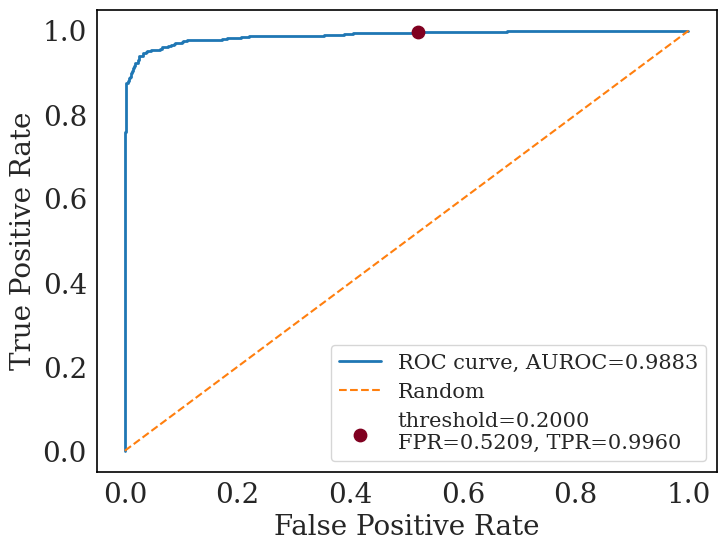

{'auroc': 0.9882768790838388, 'threshold': 0.2, 'tpr': 0.996042216358839, 'fpr': 0.5209424083769634, 'tp': 755, 'fn': 3, 'fp': 398, 'tn': 366}


In [10]:
import numpy as np
import sklearn.metrics as sk
import matplotlib.pyplot as plt

def plot_roc_with_threshold(id_scores, ood_scores, threshold, save_path=None):
    id_scores = np.asarray(id_scores).reshape(-1)
    ood_scores = np.asarray(ood_scores).reshape(-1)

    # ID 是正类 1，OOD 是负类 0
    scores = np.concatenate([id_scores, ood_scores])
    labels = np.concatenate([
        np.ones(len(id_scores)),
        np.zeros(len(ood_scores))
    ])

    # ROC 曲线
    fpr_curve, tpr_curve, thresholds = sk.roc_curve(labels, scores, pos_label=1)
    auroc = sk.roc_auc_score(labels, scores)

    # 计算你给定 threshold 下的 TPR / FPR
    id_pred_as_id = id_scores >= threshold
    ood_pred_as_id = ood_scores >= threshold

    tp = np.sum(id_pred_as_id)
    fn = np.sum(~id_pred_as_id)

    fp = np.sum(ood_pred_as_id)
    tn = np.sum(~ood_pred_as_id)

    tpr_at_threshold = tp / (tp + fn)
    fpr_at_threshold = fp / (fp + tn)

    # 画图
    plt.figure(figsize=(8, 6))
    plt.plot(fpr_curve, tpr_curve, linewidth=2, label=f"ROC curve, AUROC={auroc:.4f}")
    plt.plot([0, 1], [0, 1], linestyle="--", label="Random")

    # 标出 threshold 对应的点
    plt.scatter(
        fpr_at_threshold,
        tpr_at_threshold,
        s=80,
        color="#800020",   # 酒红色
        zorder=10,   # 关键：让点压在线上面
        label=f"threshold={threshold:.4f}\nFPR={fpr_at_threshold:.4f}, TPR={tpr_at_threshold:.4f}"
    )

    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    # plt.title("ROC Curve with Threshold")
    plt.legend()
    plt.grid(True)

    if save_path is not None:
        plt.savefig(save_path, dpi=600, bbox_inches="tight")

    plt.show()

    return {
        "auroc": auroc,
        "threshold": threshold,
        "tpr": tpr_at_threshold,
        "fpr": fpr_at_threshold,
        "tp": tp,
        "fn": fn,
        "fp": fp,
        "tn": tn,
    }

result = plot_roc_with_threshold(
    id_scores,
    ood_scores,
    threshold=0.2,
    save_path=f"./figures/roc/roc_with_threshold_{dataset_name}_{setting}_trained.pdf"
)

print(result)

cell_type
9     1132
10    1016
8      869
4      484
1      481
6      356
5      289
0      273
7      196
3      123
2       48
Name: count, dtype: int64


/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/legacy_api_wrap/__init__.py:82: UserWarning: `n_top_genes` > number of normalized dispersions, returning all genes with normalized dispersions.
  return fn(*args_all, **kw)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/site-packages/scanpy/preprocessing/_scale.py:309: UserWarning: Received a view of an AnnData. Making a copy.
  view_to_actual(adata)
/home/dids/miniconda3/envs/scOOD/lib/python3.10/functools.py:889: UserWarning: zero-centering a sparse array/matrix densifies it.
  return dispatch(args[0].__class__)(*args, **kw)


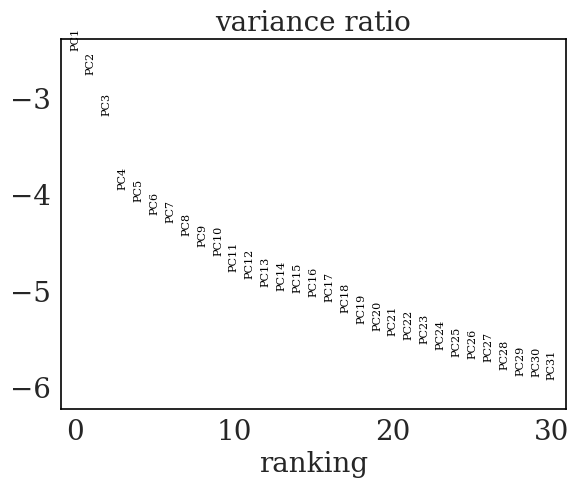

/tmp/ipykernel_1602842/2906559167.py:39: FutureWarning: In the future, the default backend for leiden will be igraph instead of leidenalg.

 To achieve the future defaults please pass: flavor="igraph" and n_iterations=2.  directed must also be False to work with igraph's implementation.
  sc.tl.leiden(adata_rna_ood, resolution=0.1)  # 0.1 0.2 0.3


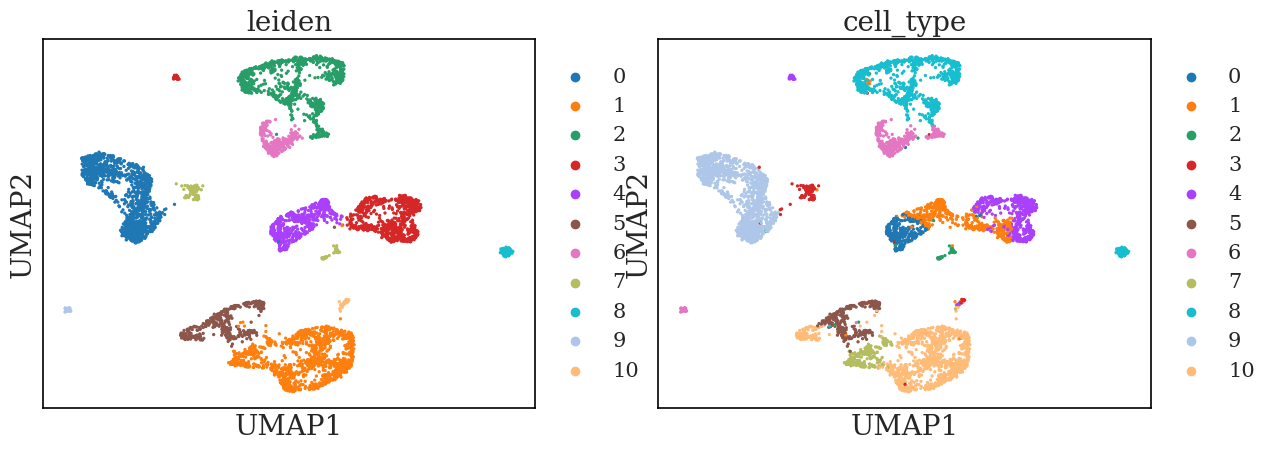

In [9]:
from scDiscovery_step3_label_OOD import leiden_pseudo_label, dataloader_to_adata, clustering_metrics_from_adata  # run_scvi,
import scanpy as sc

adata_rna_ood = dataloader_to_adata(filtered_omics1_ood_loader, label_key="cell_type")
print(adata_rna_ood.obs['cell_type'].value_counts())

sc.pp.normalize_total(adata_rna_ood, target_sum=1e4)
sc.pp.log1p(adata_rna_ood)
sc.pp.highly_variable_genes(adata_rna_ood, n_top_genes=2000)
adata_rna_ood = adata_rna_ood[:, adata_rna_ood.var.highly_variable]
sc.pp.scale(adata_rna_ood, max_value=10)

sc.tl.pca(adata_rna_ood, svd_solver='arpack')
sc.pl.pca_variance_ratio(adata_rna_ood, log=True)

sc.pp.neighbors(adata_rna_ood, n_neighbors=50, n_pcs=30) 
sc.tl.umap(adata_rna_ood)

sc.tl.leiden(adata_rna_ood, resolution=0.1)  # 0.1 0.2 0.3
sc.pl.umap(adata_rna_ood, color=['leiden', 'cell_type'])

{'ARI': 0.7938064285722929, 'AMI': 0.8267439006923784, 'NMI': 0.827563762175481, 'HOM': 0.8054812336727959}


In [11]:
from data_split import BuildDataset, DataLoader

print(adata_rna_ood)
raw_x = adata_rna_ood.obsm['raw_x']
x = adata_rna_ood.obsm['processed_x']
print(x.shape)
y = adata_rna_ood.obs['leiden']
y = y.astype('int') + class_number

raw_x = torch.tensor(raw_x)
x = torch.tensor(x)
y = torch.tensor(y)

filtered_ood_dataset = BuildDataset(raw_x, x, y)

train_id_dataset = omics1_train_loader.dataset

for _, x, y in train_id_dataset:
    print(x.shape)
    break

from torch.utils.data import ConcatDataset

merged_dataset = ConcatDataset([train_id_dataset, filtered_ood_dataset])

# for raw_x, x, y in merged_dataset:
#     print(raw_x.shape)
#     print(x.shape)
#     print(y)

merged_loader = DataLoader(
    dataset=merged_dataset, batch_size=128, shuffle=True, drop_last=True  # False
)



AnnData object with n_obs × n_vars = 5267 × 1970
    obs: 'cell_type', 'leiden'
    var: 'highly_variable', 'means', 'dispersions', 'dispersions_norm', 'mean', 'std'
    uns: 'log1p', 'hvg', 'pca', 'neighbors', 'umap', 'leiden', 'leiden_colors', 'cell_type_colors'
    obsm: 'processed_x', 'raw_x', 'X_pca', 'X_umap'
    varm: 'PCs'
    obsp: 'distances', 'connectivities'
(5267, 2000)
torch.Size([2000])


/tmp/ipykernel_1602842/350732978.py:12: FutureWarning: Series.__getitem__ treating keys as positions is deprecated. In a future version, integer keys will always be treated as labels (consistent with DataFrame behavior). To access a value by position, use `ser.iloc[pos]`
  y = torch.tensor(y)


In [12]:
from scDiscovery_step4_expand_contrastive import get_num_classes_from_loader, expand_classifier, train_encoder_classification_expand, evaluate_model_with_for_novel_class

def get_class_number_from_loader(loader):
    labels = []
    for _, _, y in loader:
        y = y.view(-1)
        labels.append(y)
    labels = torch.cat(labels)

    return int(labels.max().item() + 1)

num_classes_new = get_class_number_from_loader(merged_loader)

Classifier_expanded = expand_classifier(Classifier, num_classes_new)  # num_classes_new

optimizer_fc = optim.Adam(Classifier_expanded.parameters(), lr=0.001, weight_decay=1e-4)  # hnscc 0.0001
scheduler_fc = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_fc, T_max=100)

E_rna, D_rna, Classifier_expanded = train_decoder_classification_single_omics(E_rna, D_rna, Classifier_expanded, optimizer_E_rna, optimizer_D_rna, optimizer_fc, scheduler_E_rna, scheduler_D_rna, scheduler_fc, merged_loader, omics1_test_id_loader, num_epochs=5, device=device) # 2 3

Epoch [1/5], CLS Loss: 0.4181, RNA Recon Loss: 72.6391, RNA KL Loss: 0.9359, Acc_train: 91.95, Acc_test: 96.20
Epoch [2/5], CLS Loss: 0.2400, RNA Recon Loss: 64.7388, RNA KL Loss: 0.8465, Acc_train: 93.52, Acc_test: 95.84
Epoch [3/5], CLS Loss: 0.1945, RNA Recon Loss: 61.5064, RNA KL Loss: 0.8819, Acc_train: 94.09, Acc_test: 95.33
Epoch [4/5], CLS Loss: 0.1729, RNA Recon Loss: 58.7707, RNA KL Loss: 0.9414, Acc_train: 94.46, Acc_test: 95.32
Epoch [5/5], CLS Loss: 0.1607, RNA Recon Loss: 55.9715, RNA KL Loss: 0.9811, Acc_train: 94.88, Acc_test: 94.65


0.16518004625041294

In [14]:
to_np = lambda x: x.data.cpu().numpy()

def get_predict_for_evaluation_with_single_omics(E_rna, Classifier, omics1_mixed_loader, device):
    E_rna.eval()
    Classifier.eval()

    correct = 0
    total = 0
    y_true = []
    y_pred = []
    X_raw = []
    emb = []
    scores = []
    
    with torch.no_grad():  # 关闭梯度计算
        for x_raw, x_rna, y_rna in omics1_mixed_loader:
            x_rna = x_rna.to(device)
            y_rna = y_rna.to(device)

            z_rna, _, _ = E_rna(x_rna)

            logits = Classifier(z_rna)
            
            smax = to_np(F.softmax(logits, dim=1))

            score = np.max(smax, axis=1)  # np.max(smax, axis=1)

            _, predicted = torch.max(logits.data, 1)
            
            emb.append(z_rna.detach().cpu())
            y_true.append(y_rna.detach().cpu())
            y_pred.append(predicted.detach().cpu())
            X_raw.append(x_rna.detach().cpu())
            scores.append(score[:len(x_rna)])
            
        emb = torch.cat(emb, dim=0)  # [:max_samples]
        y_true = torch.cat(y_true, dim=0)
        y_pred = torch.cat(y_pred, dim=0)
        X_raw = torch.cat(X_raw, dim=0)
        Score = np.concatenate(scores, axis=0)
    # print(f'Accuracy of the model on the test images: {accuracy:.2f}%')
    return emb.numpy(), y_true.numpy(), y_pred.numpy(), X_raw.numpy(), Score

emb, y_true, y_pred, X_raw, ood_score = get_predict_for_evaluation_with_single_omics(E_rna, Classifier, omics1_mixed_loader, device)  #
# 正常是omics1_mixed_loader，拟时序分析时是all_data_loader

import pandas as pd
import scanpy as sc

# 1. 创建 AnnData（X 只是占位用的）
adata = sc.AnnData(X=X_raw)

adata.var["gene_symbol"] = gene_name

# 2. 放入 obs
adata.obs['y_true'] = pd.Series(y_true, index=adata.obs_names).astype(str)
adata.obs['y_pred'] = pd.Series(y_pred, index=adata.obs_names).astype(str)
adata.obs['predicted_score'] = pd.Series(ood_score, index=adata.obs_names).astype(float)

# 3. 放入 obsm
adata.obsm['X_scDiscovery'] = emb

# 4. 简单检查
print(adata)
print(adata.obs.head())
print(adata.obsm['X_scDiscovery'].shape)

###############################################
# 1. 复制原始标签（避免覆盖原数据）
y_true_new = adata.obs['y_true'].copy()
y_pred_new = adata.obs['y_pred'].copy()

# 2. 把 11 和 12 改成 "Unknown"
known_classes = [str(i) for i in range(class_number)]  # ['0','1','2','3','4','5','6']

y_true_new = y_true_new.where(y_true_new.isin(known_classes), 'Unknown')
y_pred_new = y_pred_new.where(y_pred_new.isin(known_classes), 'Unknown')


# 3. 存入 adata.obs
adata.obs['y_true_with_unknown'] = y_true_new.astype(str)
adata.obs['y_pred_with_unknown'] = y_pred_new.astype(str)

# 4. 检查
print(adata.obs[['y_true', 'y_true_with_unknown',
                 'y_pred', 'y_pred_with_unknown']].head())

# adata.write(f'./results/scDiscovery_test_{dataset_name}.h5ad')

AnnData object with n_obs × n_vars = 26071 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score'
    var: 'gene_symbol'
    obsm: 'X_scDiscovery'
  y_true y_pred  predicted_score
0      1      1         0.920553
1      3      3         0.993923
2      0      0         0.991500
3      4      4         0.652491
4      1      1         0.952507
(26071, 128)
  y_true y_true_with_unknown y_pred y_pred_with_unknown
0      1                   1      1                   1
1      3                   3      3                   3
2      0                   0      0                   0
3      4                   4      4                   4
4      1                   1      1                   1


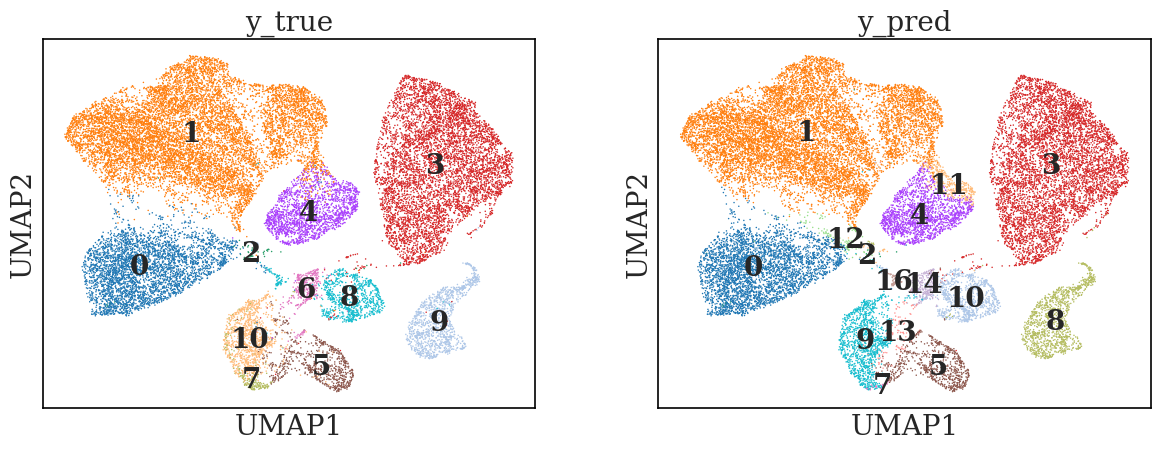

In [17]:
sc.pp.neighbors(adata, use_rep='X_scDiscovery', metric="cosine")
sc.tl.umap(adata)

sc.pl.umap(adata, color=['y_true', 'y_pred'], legend_loc='on data', save=f"_scDiscovery_umap_label_{dataset_name}_{setting}.png")



In [15]:
from metrics import evaluate_ncd_discovery_potential, calculate_discovery_asw
metrics = evaluate_ncd_discovery_potential(
    adata=adata,
    y_true='y_true_with_unknown',
    y_pred='y_pred_with_unknown',
    embed_key='X_scDiscovery',
    unknown_label='Unknown'
)

for k, v in metrics.items():
    print(f"{k}: {v}")

print(adata)
# adata.write(f'./results/scDiscovery_test_{dataset_name}_{setting}.h5ad')
# calculate_discovery_asw(adata.obsm['X_scDiscovery'], n_neighbors=15, resolution=0.5)

Coarse_F1_Macro: 0.7041927737229436
Coarse_F1_weighted: 0.9444292461764738
Coarse_ACC: 0.9514019408538222
Detection_F1_Unknown: 0.8423125615417077
Detection_Prec_Unknown: 0.7334639882410583
Detection_Recall_Unknown: 0.9890981169474727
Pred_Unk_N_Clusters: 13
Pred_Unk_ASW: 0.22831250727176666
Pred_Unk_CH: 1262.329475649215
Pure_Unk_N_Clusters: 12
Pure_Unk_ASW: 0.25026533007621765
Pure_Unk_CH: 1327.5795300864675
AnnData object with n_obs × n_vars = 26071 × 2000
    obs: 'y_true', 'y_pred', 'predicted_score', 'y_true_with_unknown', 'y_pred_with_unknown'
    var: 'gene_symbol'
    obsm: 'X_scDiscovery'


In [16]:
from sklearn.metrics import adjusted_rand_score, adjusted_mutual_info_score, normalized_mutual_info_score, homogeneity_score

def evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_train_loader, device):
    E_rna.eval()
    Classifier.eval()

    y_true = []
    y_pred = []
    recon_data = []
    emb = []

    correct = 0
    total = 0

    with torch.no_grad():  # 关闭梯度计算
        for _, x_rna, y_rna in omics1_train_loader:  # _, 
            x_rna = x_rna.to(device)
            y_rna = y_rna

            z_rna, mu_rna, logvar_rna = E_rna(x_rna)

            ###############################################
            re_z_rna = reparameterize(mu_rna, logvar_rna)

            # ---------------- decoder -----------------
            x_hat_rna = D_rna(re_z_rna)

            ###############################################

            logits = Classifier(z_rna)

            _, predicted = torch.max(logits.data, 1)

            total += logits.size(0)
            correct += (predicted.cpu() == y_rna).sum().item()

            y_true.append(y_rna)
            y_pred.append(predicted.cpu())
            recon_data.append(x_hat_rna.cpu())
            emb.append(z_rna.detach().cpu())

    accuracy = 100 * correct / total

    y_true = torch.cat(y_true, dim=0).numpy()
    y_pred = torch.cat(y_pred, dim=0).numpy()
    recon_data_rna = torch.cat(recon_data, dim=0)
    Emb = torch.cat(emb, dim=0).numpy()
    
    ari = adjusted_rand_score(y_true, y_pred)
    ami = adjusted_mutual_info_score(y_true, y_pred)
    nmi = normalized_mutual_info_score(y_true, y_pred)
    hom = homogeneity_score(y_true, y_pred)

    metrics = {
        "ARI": ari,
        "AMI": ami,
        "NMI": nmi,
        "HOM": hom
    }

    return metrics, accuracy, recon_data_rna, torch.tensor(y_true), torch.tensor(y_pred), Emb

metrics_ood, _, recon_data_ood, y_true_ood, y_pred_ood, Emb_ood = evaluate_model_on_novel_clas(E_rna, D_rna, Classifier, omics1_test_ood_loader, device)  # train_rna_loader  omics1_test_ood_loader

print("Metrics:")
for k, v in metrics_ood.items():
        print(f"{k}: {v}")

OOD Metrics:
ARI: 0.93463840034468
AMI: 0.900515774565926
NMI: 0.9008821716612766
HOM: 0.9823984515185821
Recon OOD Metrics:
ARI: 0.09243921849538665
AMI: 0.2507896808918545
NMI: 0.25334159736372724
HOM: 0.32687117933011955
Accuracy of the model on ID test images: 94.65%
Recon ID Metrics:
ARI: 0.9123706629664974
AMI: 0.8261816266340748
NMI: 0.8264340233745151
HOM: 0.8546881755510221
Accuracy of the model on ID recon test images: 91.72%
